In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
# import contextily as ctx
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans

import glob
import os
import csv
import ast
import matplotlib.patheffects as path_effects
from matplotlib.ticker import PercentFormatter

# from libpysal import weights

from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    LinearSegmentedColormap,
    TwoSlopeNorm
)

from pathlib import Path

In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

### Read in source files 

In [3]:
# study area gdfs 
new_ea = gpd.read_file(DATA_DIR / 'miscellaneous/new_ea.json')
new_data_study_area = gpd.read_file(DATA_DIR / 'miscellaneous/new_data_study_area.json')

# PQR sites 
new_sites = gpd.read_file(DATA_DIR / 'miscellaneous/new_sites.json')

# shapefile (all EAs)
filt_all_eas_dem_df = gpd.read_file(DATA_DIR / 'miscellaneous/filt_all_eas_dem_df.json')

### Mapping of EAs and PQR sites 

In [4]:
ea_copy_pqr = new_ea.copy()
ea_copy_pqr = ea_copy_pqr[['ea_code9ch', 'geometry']]
merged_sites_pqr = gpd.sjoin(new_sites, ea_copy_pqr, how = 'inner', predicate = 'intersects')

merged_sites_pqr = merged_sites_pqr[['space_grouping', 'geometry', 'ea_code9ch']].reset_index(drop=True)

grouped_sites_df = merged_sites_pqr.groupby('ea_code9ch').agg({
    'space_grouping': lambda x: list(set(x)),  
})

grouped_sites_df = grouped_sites_df.rename(columns = {'space_grouping':'site_id'})

### 2021 Census Districts 

In [5]:
# read districts shapefile for plotting 
dist_2021 = gpd.read_file(DATA_DIR / 'miscellaneous/district_2021_census.geojson')

In [6]:
### Filter out Study Area Districts 

dist_2021 = gpd.sjoin(
    dist_2021, merged_sites_pqr.to_crs('EPSG:4326'), 
    how="inner", 
    predicate='contains' 
).reset_index(drop=True).drop(columns=['index_right'])

dist_2021 = dist_2021.drop_duplicates(['Name']).reset_index(drop=True)

# reproject to local CRS 
dist_2021_transformed = dist_2021.to_crs(merged_sites_pqr.crs)

district_gdf = dist_2021_transformed.copy()

### Revised EA shapefile  

In [7]:
filt_all_eas_dem_df_filt = gpd.sjoin(
    filt_all_eas_dem_df, dist_2021_transformed.drop(columns = ['ea_code9ch']), 
    how="inner", 
    predicate='intersects' 
).reset_index(drop=True)

## exclude additional EAs around the edges for basemap plotting 
additional_eas_to_exclude = [31400149, 31400142, 31400139, 31400134, 31400133, 30801173, 30801139, 30801138, 30801136, 30801063, 30801062, 30100656, 30100652, 30200407, 30200368, 30801041, 30801001, 30100689, 30200426]

filt_all_eas_dem_df_filt = filt_all_eas_dem_df_filt[
    ~filt_all_eas_dem_df_filt['ea_code9ch'].isin(additional_eas_to_exclude)
]

## 1) Logit Results Workflow 

### `update` this df if it changes 

In [8]:
# converged_sensors_df = pd.read_csv(DATA_DIR / 'miscellaneous/converged_sensors.csv').drop(columns = ['Unnamed: 0'])
converged_sensors_df = pd.read_csv(DATA_DIR / 'miscellaneous/converged_sensors_rev1.csv').drop(columns = ['Unnamed: 0'])

sensor_list = converged_sensors_df['site_id'].unique().tolist()

### Read sensor data file from a random day that has all sites & coordinate data 

In [9]:
df = pd.read_csv(DATA_DIR / 'miscellaneous/2022-05-01.csv')

df_filt = df[df['site_id'].isin(sensor_list)]

In [10]:
list_1 = df_filt['site_id'].unique().tolist()

In [11]:
df_filt = df_filt[['time', 'respondent_id', 'site_latitude',
       'site_longitude', 'voltage', 'frequency', 'site_id']]


site_coords = (
    df_filt.groupby('site_id')[['site_latitude', 'site_longitude']]
      .first()
      .reset_index()
)

In [12]:
merged_df = converged_sensors_df.merge(
    site_coords,
    on='site_id',
    how='left'
)

merged_df = merged_df[['site_id', 'sensor_id', 'or_exposure', 'cesi_level', 'site_latitude', 'site_longitude']]

### convert to gdf 

In [13]:
import geopandas as gpd

# Convert dataframe to GeoDataFrame
sensor_gdf = gpd.GeoDataFrame(
    merged_df,
    geometry=gpd.points_from_xy(
        merged_df['site_longitude'],
        merged_df['site_latitude']
    ),
    crs='EPSG:4326'   # lat/lon CRS
)

# Convert to UTM Zone 30N
sensor_gdf = sensor_gdf.to_crs(epsg=32630)

In [14]:
sensor_gdf.head()

,site_id,sensor_id,or_exposure,cesi_level,site_latitude,site_longitude,geometry
0,4,08565208,2.255,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
1,4,6072cd14,1.285,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
2,4,d0e07e0f,1.288,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
3,4,e13978e1,1.448,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
4,20,69562a09,1.836,Low,5.698296,-0.212605,POINT (808764.997 630599.905)


### Define x&y offsets, figsize, and x&y axis limits - so the spatial figures are more centered

In [15]:
common_x_ref_offset = 4     # km east if use_km=True
common_y_ref_offset = -1 

fig_size=(10, 8)

common_xlim = (-18, 18)
common_ylim = (-12, 22)

### Mean collapsing; hide y-axis; make points more central (ref should be same) 

In [57]:
def plot_site_or_distances_from_reference_binned(
    gdf,
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=True,
    figsize=(9, 7),
    x_label_fontsize=15,

    # Sequential colors
    colors=None,

    # Binning
    n_bins=4,
    bins=None,
    bin_round=2,
    use_bins=False,

    # Plot styling
    point_size=70,
    annotate=False,
    cbar_label='Undervoltage Likelihood',
    cbar_labelpad=20,
    cbar_label_fontsize=15,
    x_rotation=0,

    # Panel label using ax.transAxes
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight='bold',
    panel_label_ha='left',
    panel_label_va='top',

    # Distance options
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,

    # Axis limits
    xlim=None,
    ylim=None,

    # Site collapsing
    collapse_sites=True,
    collapse_method='max',

    # Diverging OR cmap
    use_diverging_or_cmap=True,
    or_reference=1,

    # Colormap options
    cmap_name='RdBu_r',
    use_custom_colors=False,
    diverging_colors=None,

    # Normalization controls
    symmetric_cmap=True,
    vmin=None,
    vmax=None,

    # Colorbar ticks
    cbar_ticks=None,

    # Layout
    colorbar_fraction=0.046,
    colorbar_pad=0.04,

    # Diagnostics
    diagnostics=True,

    save_path=None,
    dpi=300
):
    import numpy as np
    import geopandas as gpd
    import matplotlib.pyplot as plt

    from matplotlib.colors import (
        BoundaryNorm,
        LinearSegmentedColormap,
        ListedColormap,
        TwoSlopeNorm
    )

    if colors is None:
        colors = [
            '#fee5d9',
            '#fcae91',
            '#fb6a4a',
            '#cb181d'
        ]

    if diverging_colors is None:
        diverging_colors = [
            '#2166ac',  # below 1 = blue
            '#67a9cf',
            '#f7f7f7',
            '#f4a582',
            '#b2182b'   # above 1 = red
        ]

    gdf = gpd.GeoDataFrame(
        gdf,
        geometry='geometry'
    ).copy()

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    # -------------------------------------------------
    # Clean invalid rows
    # -------------------------------------------------
    gdf = gdf.dropna(
        subset=['or_exposure', 'geometry']
    ).copy()

    gdf = gdf[
        ~gdf.geometry.is_empty
    ].copy()

    gdf = gdf[
        np.isfinite(gdf['or_exposure'])
    ].copy()

    gdf = gdf[
        gdf['or_exposure'] > 0
    ].copy()

    if len(gdf) == 0:
        raise ValueError(
            "No valid rows left after removing NaN/inf/zero "
            "OR values or invalid geometries."
        )

    # -------------------------------------------------
    # Collapse multiple sensors per site
    # -------------------------------------------------
    if collapse_sites:

        if collapse_method == 'max':
            idx = (
                gdf.groupby('site_id')['or_exposure']
                .idxmax()
            )

            gdf = (
                gdf.loc[idx]
                .copy()
                .reset_index(drop=True)
            )

        elif collapse_method == 'min':
            idx = (
                gdf.groupby('site_id')['or_exposure']
                .idxmin()
            )

            gdf = (
                gdf.loc[idx]
                .copy()
                .reset_index(drop=True)
            )

        elif collapse_method == 'mean':
            original_crs = gdf.crs

            gdf = (
                gdf.groupby('site_id')
                .agg(
                    or_exposure=('or_exposure', 'mean'),
                    cesi_level=('cesi_level', 'first'),
                    site_latitude=('site_latitude', 'first'),
                    site_longitude=('site_longitude', 'first'),
                    geometry=('geometry', 'first')
                )
                .reset_index()
            )

            gdf = gpd.GeoDataFrame(
                gdf,
                geometry='geometry',
                crs=original_crs
            )

        else:
            raise ValueError(
                "collapse_method must be 'max', 'min', or 'mean'"
            )

    # -------------------------------------------------
    # Point coordinates
    # -------------------------------------------------
    centroid_gdf = gdf.copy()

    centroid_gdf['easting'] = (
        centroid_gdf.geometry.x
    )

    centroid_gdf['northing'] = (
        centroid_gdf.geometry.y
    )

    # -------------------------------------------------
    # Reference point
    # -------------------------------------------------
    if use_base_df:

        if base_gdf is None:
            raise ValueError(
                "base_gdf must be provided when use_base_df=True"
            )

        base_gdf = gpd.GeoDataFrame(
            base_gdf,
            geometry='geometry'
        ).copy()

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)

        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)

        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union

        ref_point = base_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    elif use_union_centroid:

        try:
            combined_geom = gdf.geometry.union_all()
        except Exception:
            combined_geom = gdf.geometry.unary_union

        ref_point = combined_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    else:

        if ref_easting is None:
            ref_easting = centroid_gdf['easting'].mean()

        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    # -------------------------------------------------
    # Apply reference offset
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000
    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

    # -------------------------------------------------
    # Distances
    # -------------------------------------------------
    centroid_gdf['x_distance'] = (
        centroid_gdf['easting'] - ref_easting
    )

    centroid_gdf['y_distance'] = (
        centroid_gdf['northing'] - ref_northing
    )

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000

        x_label = (
            'East-West distance from reference (km)'
        )
    else:
        x_label = (
            'East-West distance from reference (m)'
        )

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if diagnostics:
        print("\n--- Plot diagnostics ---")
        print(
            "Rows after cleaning/collapse:",
            len(centroid_gdf)
        )
        print("CRS:", centroid_gdf.crs)

        print("\nFinite checks:")
        print(
            "x finite:",
            np.isfinite(
                centroid_gdf['x_distance']
            ).all()
        )
        print(
            "y finite:",
            np.isfinite(
                centroid_gdf['y_distance']
            ).all()
        )
        print(
            "OR finite:",
            np.isfinite(
                centroid_gdf['or_exposure']
            ).all()
        )
        print(
            "ref_easting finite:",
            np.isfinite(ref_easting)
        )
        print(
            "ref_northing finite:",
            np.isfinite(ref_northing)
        )
        print(
            "x_ref_offset finite:",
            np.isfinite(x_ref_offset)
        )
        print(
            "y_ref_offset finite:",
            np.isfinite(y_ref_offset)
        )

        print("\nRanges:")
        print(
            "x range:",
            centroid_gdf['x_distance'].min(),
            centroid_gdf['x_distance'].max()
        )
        print(
            "y range:",
            centroid_gdf['y_distance'].min(),
            centroid_gdf['y_distance'].max()
        )
        print(
            "OR range:",
            centroid_gdf['or_exposure'].min(),
            centroid_gdf['or_exposure'].max()
        )

        print("\nReference point:")
        print("ref_easting:", ref_easting)
        print("ref_northing:", ref_northing)

        print("\nAxis limits passed:")
        print("xlim:", xlim)
        print("ylim:", ylim)

        if xlim is not None:
            print(
                "xlim finite:",
                all(np.isfinite(v) for v in xlim)
            )

        if ylim is not None:
            print(
                "ylim finite:",
                all(np.isfinite(v) for v in ylim)
            )

        print("------------------------\n")

    # -------------------------------------------------
    # Data range
    # -------------------------------------------------
    or_min = centroid_gdf['or_exposure'].min()
    or_max = centroid_gdf['or_exposure'].max()

    # -------------------------------------------------
    # Determine plotting range
    # -------------------------------------------------
    if (
        symmetric_cmap
        and vmin is None
        and vmax is None
    ):
        distance_below = abs(
            or_reference - or_min
        )

        distance_above = abs(
            or_max - or_reference
        )

        max_distance = max(
            distance_below,
            distance_above
        )

        vmin_plot = (
            or_reference - max_distance
        )

        vmax_plot = (
            or_reference + max_distance
        )

        vmin_plot = max(vmin_plot, 0)

    else:
        vmin_plot = (
            vmin if vmin is not None else or_min
        )

        vmax_plot = (
            vmax if vmax is not None else or_max
        )

    if vmin_plot >= vmax_plot:
        raise ValueError(
            f"Invalid color scale: "
            f"vmin_plot={vmin_plot}, "
            f"vmax_plot={vmax_plot}"
        )

    # -------------------------------------------------
    # Colormap
    # -------------------------------------------------
    if use_diverging_or_cmap and not use_bins:

        if use_custom_colors:
            cmap = LinearSegmentedColormap.from_list(
                "custom_or_diverging_cmap",
                diverging_colors
            )
        else:
            cmap = plt.get_cmap(cmap_name)

        if vmin_plot < or_reference < vmax_plot:
            norm = TwoSlopeNorm(
                vmin=vmin_plot,
                vcenter=or_reference,
                vmax=vmax_plot
            )
        else:
            print(
                f"Warning: OR reference {or_reference} "
                f"is outside plotting range "
                f"({vmin_plot:.3f}, {vmax_plot:.3f}). "
                "Using regular normalization."
            )
            norm = None

    elif use_bins:

        cmap = ListedColormap(colors)

        if bins is None:
            bins = np.linspace(
                vmin_plot,
                vmax_plot,
                n_bins + 1
            )

            bins = np.round(
                bins,
                bin_round
            )

            bins = np.unique(bins)

        norm = BoundaryNorm(
            bins,
            cmap.N,
            clip=True
        )

    else:

        cmap = LinearSegmentedColormap.from_list(
            "smooth_custom_cmap",
            colors
        )

        norm = None

    # -------------------------------------------------
    # Create figure and axes
    # -------------------------------------------------
    fig, ax = plt.subplots(
        figsize=figsize
    )

    # -------------------------------------------------
    # Scatter plot
    # -------------------------------------------------
    sc = ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['or_exposure'],
        cmap=cmap,
        norm=norm,
        s=point_size,
        alpha=0.9,
        vmin=None if norm is not None else vmin_plot,
        vmax=None if norm is not None else vmax_plot
    )

    ax.axhline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    ax.axvline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    # -------------------------------------------------
    # Panel label using axes coordinates
    # -------------------------------------------------
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            horizontalalignment=panel_label_ha,
            verticalalignment=panel_label_va,
            clip_on=False,
            zorder=10
        )

    # -------------------------------------------------
    # Site annotations
    # -------------------------------------------------
    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.text(
                row['x_distance'],
                row['y_distance'],
                str(row['site_id']),
                fontsize=8
            )

    # -------------------------------------------------
    # Colorbar
    # -------------------------------------------------
    cbar = plt.colorbar(
        sc,
        ax=ax,
        fraction=colorbar_fraction,
        pad=colorbar_pad
    )

    cbar.set_label(
        cbar_label,
        fontsize=cbar_label_fontsize,
        fontweight='bold',
        labelpad=cbar_labelpad
    )

    if cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)

    cbar.ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _: f'{x:g}X'
        )
    )

    # -------------------------------------------------
    # Axes
    # -------------------------------------------------
    ax.set_xlabel(
        x_label,
        fontsize=x_label_fontsize,
        fontweight='bold',
        labelpad=15
    )

    # Hide y-axis
    ax.yaxis.set_visible(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.tick_params(
        axis='x',
        labelrotation=x_rotation,
        labelsize=12,
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    return centroid_gdf

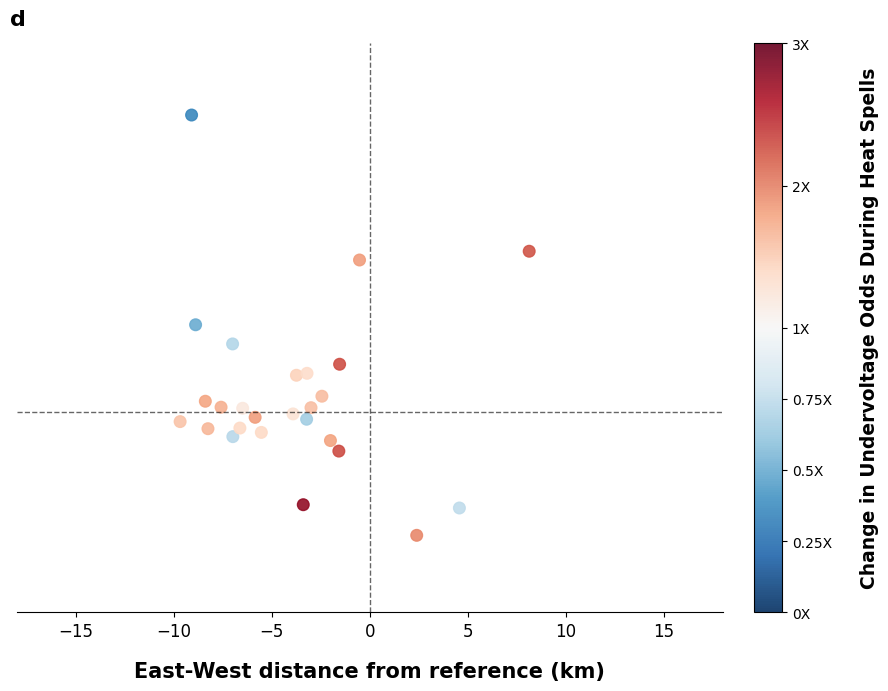

In [60]:
site_or_centroid = plot_site_or_distances_from_reference_binned(
    sensor_gdf,
    figsize=(9, 7),

    # Panel label
    panel_label='d',
    panel_label_x=-0.01,
    panel_label_y=1.06,
    panel_label_fontsize=16,

    cbar_label='Change in Undervoltage Odds During Heat Spells',
    use_bins=False,
    symmetric_cmap=False,
    collapse_method='mean',
    vmin=0,
    vmax=3,
    cbar_ticks=[0, 0.25, 0.5, 0.75, 1, 2, 3],
    or_reference=1,
    cmap_name='RdBu_r',
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False,
    x_label_fontsize=15,
    cbar_label_fontsize=13.5,
    save_path=PLOTS_DIR / 'spatial_logit_undervolt_rev1.png',
)

## 2) OLS Results Workflow 

### check number of unique sites in the df 

In [18]:
ols_per_sensor = pd.read_csv(DATA_DIR / 'miscellaneous/ols_per_sensor_results.csv').drop(columns=['Unnamed: 0'])
ols_sensor_list = ols_per_sensor['site_id'].unique().tolist()

### filter & get geometries from main `sample df` 

In [19]:
df = pd.read_csv(DATA_DIR / 'miscellaneous/2022-05-01.csv')
df_filt_ols = df[df['site_id'].isin(ols_sensor_list)]

In [20]:
df_filt_ols = df_filt_ols[['time', 'respondent_id', 'site_latitude',
       'site_longitude', 'voltage', 'frequency', 'site_id']]

site_coords_ols = (
    df_filt_ols.groupby('site_id')[['site_latitude', 'site_longitude']]
      .first()
      .reset_index()
)

merged_df_ols = ols_per_sensor.merge(
    site_coords_ols,
    on='site_id',
    how='left'
)

### convert to gdf 

In [21]:
import geopandas as gpd

# Convert dataframe to GeoDataFrame
sensor_ols_gdf = gpd.GeoDataFrame(
    merged_df_ols,
    geometry=gpd.points_from_xy(
        merged_df_ols['site_longitude'],
        merged_df_ols['site_latitude']
    ),
    crs='EPSG:4326'   # lat/lon CRS
)

# Convert to UTM Zone 30N
sensor_ols_gdf = sensor_ols_gdf.to_crs(epsg=32630)

In [22]:
sensor_ols_gdf.head()

,site_id,sensor_id,coef_Temp,sig_Temp,cesi_level,site_latitude,site_longitude,geometry
0,1,bb3ff846,-1.297078,True,Low,5.619831,-0.221795,POINT (807787.767 621911.325)
1,2,e2e26a75,-1.410181,True,Low,5.588561,-0.224331,POINT (807523.002 618449.386)
2,2,e39a61a6,-1.915402,True,Low,5.588561,-0.224331,POINT (807523.002 618449.386)
3,3,14618a70,-0.784692,True,Low,5.676189,-0.277559,POINT (801576 628119)
4,3,377f44ed,-1.503098,True,Low,5.676189,-0.277559,POINT (801576 628119)


### Just showing the negative values; hide the y-axis 

In [47]:
def plot_site_coef_distances_negative_only(
    gdf,
    value_col='coef_Temp',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    cbar_label_fontsize=15,
    x_label_fontsize=15,

    # Plot styling
    point_size=70,
    annotate=False,
    cbar_label='Voltage Sensitivity to Temperature (ΔV/°C)',
    cbar_labelpad=20,
    x_rotation=45,

    # Panel label using ax.transAxes
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight='bold',
    panel_label_ha='left',
    panel_label_va='top',

    # Distance options
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,

    # Axis limits
    xlim=None,
    ylim=None,

    # Site collapsing
    collapse_sites=True,
    collapse_method='mean',

    # Significance filtering
    sig_col=None,
    keep_only_sig=False,

    # Colorbar layout
    colorbar_fraction=0.046,
    colorbar_pad=0.04,

    # Color scale
    vmin=None,
    vmax=None,

    # Diagnostics
    diagnostics=False,

    # Saving
    save_path=None,
    dpi=300
):
    """
    Plot negative coefficient values using a sequential red colormap.

    Darker red represents more-negative coefficients, while lighter red
    represents coefficients closer to zero. The y-axis is hidden, and a
    vertical reference line is drawn at an east-west distance of zero.

    The panel label uses axes-relative coordinates, where (0, 0) is the
    bottom-left and (1, 1) is the top-right of the plotting axes.
    """

    import numpy as np
    import geopandas as gpd
    import matplotlib.pyplot as plt

    # -------------------------------------------------
    # Convert to GeoDataFrame
    # -------------------------------------------------
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry='geometry'
    ).copy()

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    # -------------------------------------------------
    # Optional significance filtering
    # -------------------------------------------------
    if keep_only_sig:
        if sig_col is None:
            raise ValueError(
                "sig_col must be provided when keep_only_sig=True."
            )

        if sig_col not in gdf.columns:
            raise ValueError(
                f"Significance column '{sig_col}' was not found."
            )

        gdf = gdf[
            gdf[sig_col] == True
        ].copy()

    # -------------------------------------------------
    # Clean invalid rows
    # -------------------------------------------------
    gdf = gdf.dropna(
        subset=[value_col, 'geometry']
    ).copy()

    gdf = gdf[
        ~gdf.geometry.is_empty
    ].copy()

    gdf = gdf[
        np.isfinite(gdf[value_col])
    ].copy()

    # -------------------------------------------------
    # Keep only negative values
    # -------------------------------------------------
    gdf = gdf[
        gdf[value_col] < 0
    ].copy()

    if len(gdf) == 0:
        raise ValueError(
            f"No negative values found in column '{value_col}'."
        )

    # -------------------------------------------------
    # Collapse multiple sensors per site
    # -------------------------------------------------
    if collapse_sites:

        if collapse_method == 'max':
            idx = (
                gdf.groupby('site_id')[value_col]
                .idxmax()
            )

            gdf = (
                gdf.loc[idx]
                .copy()
                .reset_index(drop=True)
            )

        elif collapse_method == 'min':
            idx = (
                gdf.groupby('site_id')[value_col]
                .idxmin()
            )

            gdf = (
                gdf.loc[idx]
                .copy()
                .reset_index(drop=True)
            )

        elif collapse_method == 'mean':
            original_crs = gdf.crs

            agg_dict = {
                value_col: (value_col, 'mean'),
                'geometry': ('geometry', 'first')
            }

            # Include these columns only if they exist
            optional_columns = [
                'cesi_level',
                'site_latitude',
                'site_longitude'
            ]

            for column in optional_columns:
                if column in gdf.columns:
                    agg_dict[column] = (
                        column,
                        'first'
                    )

            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (
                    sig_col,
                    'max'
                )

            gdf = (
                gdf.groupby('site_id')
                .agg(**agg_dict)
                .reset_index()
            )

            gdf = gpd.GeoDataFrame(
                gdf,
                geometry='geometry',
                crs=original_crs
            )

        else:
            raise ValueError(
                "collapse_method must be 'max', 'min', or 'mean'."
            )

    # -------------------------------------------------
    # Point coordinates
    # -------------------------------------------------
    centroid_gdf = gdf.copy()

    centroid_gdf['easting'] = (
        centroid_gdf.geometry.x
    )

    centroid_gdf['northing'] = (
        centroid_gdf.geometry.y
    )

    # -------------------------------------------------
    # Determine reference point
    # -------------------------------------------------
    if use_base_df:

        if base_gdf is None:
            raise ValueError(
                "base_gdf must be provided when use_base_df=True."
            )

        base_gdf = gpd.GeoDataFrame(
            base_gdf,
            geometry='geometry'
        ).copy()

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)

        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)

        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union

        ref_point = base_geom.centroid

        ref_easting = ref_point.x
        ref_northing = ref_point.y

    elif use_union_centroid:

        try:
            combined_geom = (
                centroid_gdf.geometry.union_all()
            )
        except Exception:
            combined_geom = (
                centroid_gdf.geometry.unary_union
            )

        ref_point = combined_geom.centroid

        ref_easting = ref_point.x
        ref_northing = ref_point.y

    else:

        if ref_easting is None:
            ref_easting = (
                centroid_gdf['easting'].mean()
            )

        if ref_northing is None:
            ref_northing = (
                centroid_gdf['northing'].mean()
            )

    # -------------------------------------------------
    # Apply reference offsets
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000

    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

    # -------------------------------------------------
    # Calculate distances
    # -------------------------------------------------
    centroid_gdf['x_distance'] = (
        centroid_gdf['easting'] - ref_easting
    )

    centroid_gdf['y_distance'] = (
        centroid_gdf['northing'] - ref_northing
    )

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000

        x_label = (
            'East-West distance from reference (km)'
        )

    else:
        x_label = (
            'East-West distance from reference (m)'
        )

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if diagnostics:
        print(
            "\n--- Plot diagnostics (negative-only) ---"
        )

        print(
            "Rows after negative filter:",
            len(centroid_gdf)
        )

        print(
            f"{value_col} range:",
            centroid_gdf[value_col].min(),
            centroid_gdf[value_col].max()
        )

        print(
            "x range:",
            centroid_gdf['x_distance'].min(),
            centroid_gdf['x_distance'].max()
        )

        print(
            "y range:",
            centroid_gdf['y_distance'].min(),
            centroid_gdf['y_distance'].max()
        )

        print(
            "Reference easting:",
            ref_easting
        )

        print(
            "Reference northing:",
            ref_northing
        )

        print(
            "xlim:",
            xlim
        )

        print(
            "ylim:",
            ylim
        )

        print(
            "----------------------------------------\n"
        )

    # -------------------------------------------------
    # Colormap
    #
    # Reds_r gives:
    # More negative = darker red
    # Closer to zero = lighter red
    # -------------------------------------------------
    cmap = plt.get_cmap('Reds_r')

    vmin_plot = (
        vmin
        if vmin is not None
        else centroid_gdf[value_col].min()
    )

    vmax_plot = (
        vmax
        if vmax is not None
        else 0.0
    )

    if vmin_plot >= vmax_plot:
        raise ValueError(
            f"Invalid color scale: "
            f"vmin={vmin_plot} must be less than "
            f"vmax={vmax_plot}."
        )

    # -------------------------------------------------
    # Create figure and axes
    # -------------------------------------------------
    fig, ax = plt.subplots(
        figsize=figsize
    )

    # -------------------------------------------------
    # Scatter plot
    # -------------------------------------------------
    sc = ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf[value_col],
        cmap=cmap,
        vmin=vmin_plot,
        vmax=vmax_plot,
        s=point_size,
        alpha=0.9
    )

    # -------------------------------------------------
    # Vertical reference line at E-W distance = 0
    # -------------------------------------------------
    ax.axvline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    # -------------------------------------------------
    # Panel label using axes-relative coordinates
    # -------------------------------------------------
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            horizontalalignment=panel_label_ha,
            verticalalignment=panel_label_va,
            clip_on=False,
            zorder=10
        )

    # -------------------------------------------------
    # Optional site annotations
    # -------------------------------------------------
    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.text(
                row['x_distance'],
                row['y_distance'],
                str(row['site_id']),
                fontsize=8
            )

    # -------------------------------------------------
    # Colorbar
    # -------------------------------------------------
    cbar = plt.colorbar(
        sc,
        ax=ax,
        fraction=colorbar_fraction,
        pad=colorbar_pad
    )

    cbar.set_label(
        cbar_label,
        fontsize=cbar_label_fontsize,
        fontweight='bold',
        labelpad=cbar_labelpad
    )

    # Colorbar tick-label size
    cbar.ax.tick_params(
        labelsize=10.5
    )

    # -------------------------------------------------
    # Axes
    # -------------------------------------------------
    ax.set_xlabel(
        x_label,
        fontsize=x_label_fontsize,
        fontweight='bold',
        labelpad=15
    )

    # Hide y-axis
    ax.yaxis.set_visible(False)

    # Remove all spines except the bottom
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.tick_params(
    axis='x',
    labelsize=12,
    labelrotation=x_rotation
)

    plt.tight_layout()

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    return centroid_gdf

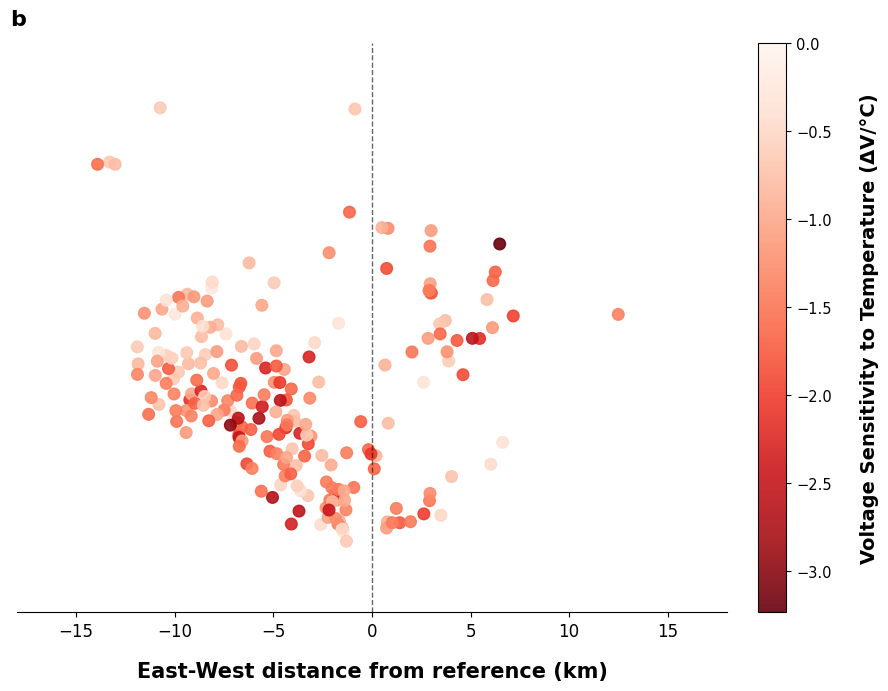

In [53]:
coef_temp_neg = plot_site_coef_distances_negative_only(
    sensor_ols_gdf,
    value_col='coef_Temp',
    use_union_centroid=True,

    figsize=(9, 7),

    # Panel label
    panel_label='b',
    panel_label_x=-0.01,
    panel_label_y=1.06,
    panel_label_fontsize=16,

    # Font sizes
    cbar_label_fontsize=14,
    x_label_fontsize=15,
    x_rotation=0,

    # Distance settings
    use_km=True,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,

    # Common plot limits
    xlim=common_xlim,
    ylim=common_ylim,

    diagnostics=False,

    save_path=(PLOTS_DIR /'spatial_clustering_sensor_coefficients.png'),
)

### Filter sensors - (coeff 0 or below; and classify `coef_Temp` as high or low based on median) 

In [25]:
# Filter to coef_Temp <= 0
sensor_ols_gdf_filtered = sensor_ols_gdf[sensor_ols_gdf['coef_Temp'] <= 0].copy()

# Calculate median of the filtered subset
median_coef = sensor_ols_gdf_filtered['coef_Temp'].median()

# Categorize: values <= median are more negative → "High" effect; above median → "Low" effect
sensor_ols_gdf_filtered['coef_Temp_category'] = sensor_ols_gdf_filtered['coef_Temp'].apply(
    lambda x: 'High' if x <= median_coef else 'Low'
)

### Simpler Version 

In [26]:
def plot_site_coef_bivariate(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    # --- legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Voltage Sensitivity',
    legend_y_label='CESI',
    legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=0,
    legend_x_label_offset=-0.55,
    legend_y_label_offset=-0.55,
    legend_x_tick_offset=-0.1,
    legend_y_tick_offset=-0.1,
    diagnostics=True,
    save_path=None,
    dpi=300
):
    """
    Plots coefficient values using a bivariate colour scheme.

    Two dimensions:
      - coef_Temp magnitude : Low (above median) vs High (at/below median)
      - cesi_level          : Low vs High

    Colour mixing:
      - Coef axis : blue (#2166ac) → red  (#b2182b)
      - CESI axis : light (low)    → dark (high)

    Y-axis is hidden; only a dashed axvline at x=0 is drawn.
    Only values <= 0 are plotted.
    """

    BIVAR_COLORS = {
        ('Low',  'Low'):  '#a6c6e8',
        ('High', 'Low'):  '#f4a582',
        ('Low',  'High'): '#2166ac',
        ('High', 'High'): '#b2182b',
    }

    # ------------------------------------------------------------------
    # Prep
    # ------------------------------------------------------------------
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry', cesi_col]).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # Keep only zero and negative values
    gdf = gdf[gdf[value_col] <= 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No values <= 0 found in column '{value_col}'.")

    # ------------------------------------------------------------------
    # Collapse
    # ------------------------------------------------------------------
    if collapse_sites:
        if collapse_method in ('max', 'min'):
            idx = (gdf.groupby('site_id')[value_col].idxmax()
                   if collapse_method == 'max'
                   else gdf.groupby('site_id')[value_col].idxmin())
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs
            agg_dict = {
                value_col:        (value_col, 'mean'),
                cesi_col:         (cesi_col, 'first'),
                'site_latitude':  ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry':       ('geometry', 'first'),
            }
            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = gdf.groupby('site_id').agg(**agg_dict).reset_index()
            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)
        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # ------------------------------------------------------------------
    # Bivariate categories
    # ------------------------------------------------------------------
    median_coef = gdf[value_col].median()
    gdf['coef_cat'] = np.where(gdf[value_col] <= median_coef, 'High', 'Low')
    gdf['cesi_cat'] = gdf[cesi_col].astype(str).str.strip().str.capitalize()
    gdf['bv_color'] = [
        BIVAR_COLORS.get((r['coef_cat'], r['cesi_cat']), '#cccccc')
        for _, r in gdf.iterrows()
    ]

    # ------------------------------------------------------------------
    # Coordinates & reference
    # ------------------------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting']  = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:
        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")
        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()
        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)
        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)
        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union
        ref_easting  = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union
        ref_easting  = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting  is None:
            ref_easting  = centroid_gdf['easting'].mean()
        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    scale = 1000 if use_km else 1
    ref_easting  += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    centroid_gdf['x_distance'] = (centroid_gdf['easting']  - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'East–West distance from reference (km)'
    else:
        x_label = 'East–West distance from reference (m)'

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    if diagnostics:
        print("\n--- Bivariate plot diagnostics ---")
        print(f"Rows plotted : {len(centroid_gdf)}")
        print(f"Median coef  : {median_coef:.4f}")
        print(f"coef_cat counts:\n{centroid_gdf['coef_cat'].value_counts()}")
        print(f"cesi_cat counts:\n{centroid_gdf['cesi_cat'].value_counts()}")

        for cat in ['Low', 'High']:
            sub = centroid_gdf[centroid_gdf['coef_cat'] == cat][value_col]
            if len(sub) > 0:
                print(
                    f"\n'{cat}' sensitivity range: "
                    f"[{sub.min():.4f}, {sub.max():.4f}]  "
                    f"(n={len(sub)})"
                )
            else:
                print(f"\n'{cat}' sensitivity range: no rows")

        print("----------------------------------\n")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4,
    )

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=7, ha='left', va='bottom',
            )

    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    # ------------------------------------------------------------------
    # Bivariate inset legend
    # ------------------------------------------------------------------
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,
        legend_cell_size * 2,
    )

    _add_bivariate_legend(
        ax,
        BIVAR_COLORS,
        bbox=legend_bbox,
        x_label=legend_x_label,
        y_label=legend_y_label,
        coef_labels=legend_coef_labels,
        cesi_labels=legend_cesi_labels,
        x_tick_rotation=legend_x_tick_rotation,
        x_label_offset=legend_x_label_offset,
        y_label_offset=legend_y_label_offset,
        x_tick_offset=legend_x_tick_offset,
        y_tick_offset=legend_y_tick_offset,
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    return centroid_gdf


# ----------------------------------------------------------------------
# Helper
# ----------------------------------------------------------------------
def _add_bivariate_legend(
    ax, colors, bbox, x_label, y_label,
    coef_labels, cesi_labels,
    x_tick_rotation=0,
    x_label_offset=-0.55,
    y_label_offset=-0.55,
    x_tick_offset=-0.1,
    y_tick_offset=-0.1,
):
    """
    Draws a compact 2×2 bivariate legend as an inset axes.

    Offset params (all in data coords of the inset axes, grid spans 0-2):
      x_label_offset : y position of the x-axis label  (more negative = further below)
      y_label_offset : x position of the y-axis label  (more negative = further left)
      x_tick_offset  : y position of x tick labels     (more negative = further below)
      y_tick_offset  : x position of y tick labels     (more negative = further left)
    """

    axins = ax.inset_axes(bbox)
    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    # row 0 = CESI Low (bottom), row 1 = CESI High (top)
    grid = [
        [('Low',  'Low'),  ('High', 'Low') ],
        [('Low',  'High'), ('High', 'High')],
    ]

    for row_idx, row in enumerate(grid):
        for col_idx, (coef_cat, cesi_cat) in enumerate(row):
            colour = colors.get((coef_cat, cesi_cat), '#cccccc')
            rect = mpatches.FancyBboxPatch(
                (col_idx, row_idx), 1, 1,
                boxstyle='square,pad=0',
                facecolor=colour,
                edgecolor='white',
                linewidth=1.5,
            )
            axins.add_patch(rect)

    fs_label = 10
    fs_tick  = 8.5

    # Axis labels
    axins.text(1.0, x_label_offset, x_label,
               ha='center', va='top', fontsize=fs_label, fontweight='bold',
               transform=axins.transData)
    axins.text(y_label_offset, 1.0, y_label,
               ha='right', va='center', fontsize=fs_label, fontweight='bold',
               rotation=90, transform=axins.transData)

    # X-axis tick labels (coef ranges)
    for col_idx, label in enumerate(coef_labels):
        axins.text(col_idx + 0.5, x_tick_offset, label,
                   ha='right', va='top', fontsize=fs_tick,
                   rotation=x_tick_rotation,
                   rotation_mode='anchor',
                   transform=axins.transData)

    # Y-axis tick labels (cesi ranges)
    for row_idx, label in enumerate(cesi_labels):
        axins.text(y_tick_offset, row_idx + 0.5, label,
                   ha='right', va='center', fontsize=fs_tick,
                   transform=axins.transData)

    # Arrows
    axins.annotate('', xy=(2.15, -0.45), xytext=(0.0, -0.45),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    axins.annotate('', xy=(-0.45, 2.15), xytext=(-0.45, 0.0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

### filtering only the negative ones 

In [27]:
sensor_ols_gdf_filt = sensor_ols_gdf[sensor_ols_gdf['coef_Temp'] <= 0]

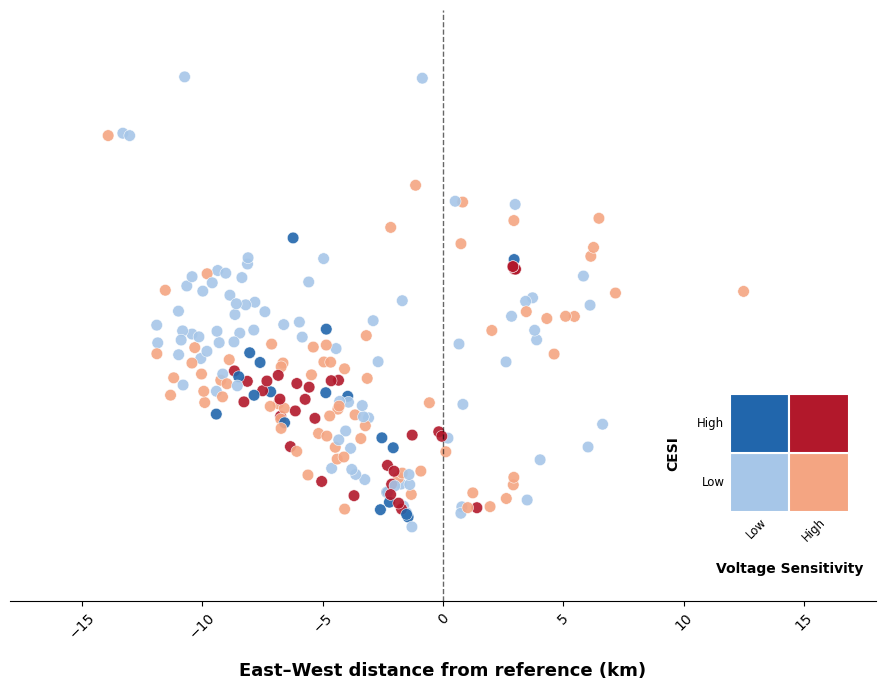

In [28]:
coef_temp_neg = plot_site_coef_bivariate(
    sensor_ols_gdf_filt,
    value_col='coef_Temp',
    use_union_centroid=True,
    use_km=True,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False,
    legend_cell_size=0.10,
    legend_pos=(0.80, 0.15),
    legend_coef_labels=('Low', 'High'),
    # legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=45,
    legend_x_label_offset=-0.85,   # x-axis label distance below grid
    legend_y_label_offset=-0.85,   # y-axis label distance left of grid
    legend_x_tick_offset=-0.05,     # x tick labels distance below grid
    legend_y_tick_offset=-0.1,     # y tick labels distance left of grid
    # save_path='spatial_clustering_bivar.png'
)

In [29]:
# Sensor-level (no collapse)
sensor_ols_gdf_filt.groupby('cesi_level')['coef_Temp'].describe()

,count,mean,std,min,25%,50%,75%,max
cesi_level,,,,,,,,
High,91.0,-1.487401,0.649318,-3.037652,-1.775405,-1.418966,-1.064821,-0.250613
Low,280.0,-1.172786,0.625969,-4.062061,-1.556312,-1.022411,-0.694108,-0.211809


In [30]:
# Site-level (after collapse)
site_level_df = (
    sensor_ols_gdf_filt
    .groupby('site_id')
    .agg(
        coef_Temp=('coef_Temp', 'mean'),
        cesi_level=('cesi_level', 'first')
    )
    .reset_index()
)

site_level_df.groupby('cesi_level')['coef_Temp'].describe()

,count,mean,std,min,25%,50%,75%,max
cesi_level,,,,,,,,
High,51.0,-1.439055,0.638108,-2.786919,-1.769011,-1.436133,-0.988904,-0.293771
Low,159.0,-1.204827,0.565664,-3.232737,-1.559377,-1.129975,-0.761024,-0.257025


### trying different colors 

In [34]:
def plot_site_coef_bivariate(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),

    # --- Plot styling ---
    point_size=70,
    annotate=False,
    x_rotation=45,
    x_label_fontsize=13,

    # --- Panel label using ax.transAxes ---
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight='bold',
    panel_label_ha='left',
    panel_label_va='top',

    # --- Distance options ---
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,

    # --- Axis limits ---
    xlim=None,
    ylim=None,

    # --- Site collapsing ---
    collapse_sites=True,
    collapse_method='mean',

    # --- Significance filtering ---
    sig_col=None,
    keep_only_sig=False,

    # --- Quadrant colors ---
    quadrant_colors=None,

    # --- Bivariate legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Voltage Sensitivity',
    legend_y_label='CESI',
    legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=0,
    legend_x_label_offset=-0.55,
    legend_y_label_offset=-0.55,
    legend_x_tick_offset=-0.1,
    legend_y_tick_offset=-0.1,

    # --- Diagnostics and saving ---
    diagnostics=True,
    save_path=None,
    dpi=300
):
    """
    Plot non-positive temperature coefficients using a bivariate scheme.

    The two dimensions are:

    - Coefficient magnitude: Low versus High sensitivity
    - CESI level: Low versus High CESI

    The panel label uses axes-relative coordinates, where (0, 0) is the
    lower-left and (1, 1) is the upper-right of the plotting axes.
    """

    import numpy as np
    import geopandas as gpd
    import matplotlib.pyplot as plt

    # -------------------------------------------------
    # Default bivariate colors
    # -------------------------------------------------
    default_quadrant_colors = {
        ('Low', 'Low'): '#a6c6e8',
        ('High', 'Low'): '#f4a582',
        ('Low', 'High'): '#2166ac',
        ('High', 'High'): '#b2182b'
    }

    if quadrant_colors is None:
        quadrant_colors = default_quadrant_colors
    else:
        merged_colors = default_quadrant_colors.copy()
        merged_colors.update(quadrant_colors)
        quadrant_colors = merged_colors

    # -------------------------------------------------
    # Prepare GeoDataFrame
    # -------------------------------------------------
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry='geometry'
    ).copy()

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    # -------------------------------------------------
    # Optional significance filtering
    # -------------------------------------------------
    if keep_only_sig:
        if sig_col is None:
            raise ValueError(
                'sig_col must be provided when keep_only_sig=True.'
            )

        if sig_col not in gdf.columns:
            raise ValueError(
                f"Significance column '{sig_col}' was not found."
            )

        gdf = gdf[
            gdf[sig_col] == True
        ].copy()

    # -------------------------------------------------
    # Remove invalid observations
    # -------------------------------------------------
    gdf = gdf.dropna(
        subset=[value_col, 'geometry', cesi_col]
    ).copy()

    gdf = gdf[
        ~gdf.geometry.is_empty
    ].copy()

    gdf = gdf[
        np.isfinite(gdf[value_col])
    ].copy()

    # Keep zero and negative coefficients
    gdf = gdf[
        gdf[value_col] <= 0
    ].copy()

    if len(gdf) == 0:
        raise ValueError(
            f"No values <= 0 found in column '{value_col}'."
        )

    # -------------------------------------------------
    # Collapse multiple sensors per site
    # -------------------------------------------------
    if collapse_sites:

        if collapse_method in ('max', 'min'):
            grouped = gdf.groupby('site_id')[value_col]

            if collapse_method == 'max':
                idx = grouped.idxmax()
            else:
                idx = grouped.idxmin()

            gdf = (
                gdf.loc[idx]
                .copy()
                .reset_index(drop=True)
            )

        elif collapse_method == 'mean':
            original_crs = gdf.crs

            agg_dict = {
                value_col: (value_col, 'mean'),
                cesi_col: (cesi_col, 'first'),
                'geometry': ('geometry', 'first')
            }

            optional_columns = [
                'site_latitude',
                'site_longitude'
            ]

            for column in optional_columns:
                if column in gdf.columns:
                    agg_dict[column] = (
                        column,
                        'first'
                    )

            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (
                    sig_col,
                    'max'
                )

            gdf = (
                gdf.groupby('site_id')
                .agg(**agg_dict)
                .reset_index()
            )

            gdf = gpd.GeoDataFrame(
                gdf,
                geometry='geometry',
                crs=original_crs
            )

        else:
            raise ValueError(
                "collapse_method must be 'max', 'min', or 'mean'."
            )

    # -------------------------------------------------
    # Create bivariate categories
    # -------------------------------------------------
    median_coef = gdf[value_col].median()

    # More-negative coefficients are categorized as
    # higher temperature sensitivity.
    gdf['coef_cat'] = np.where(
        gdf[value_col] <= median_coef,
        'High',
        'Low'
    )

    gdf['cesi_cat'] = (
        gdf[cesi_col]
        .astype(str)
        .str.strip()
        .str.capitalize()
    )

    gdf['bv_color'] = [
        quadrant_colors.get(
            (row['coef_cat'], row['cesi_cat']),
            '#cccccc'
        )
        for _, row in gdf.iterrows()
    ]

    # -------------------------------------------------
    # Point coordinates
    # -------------------------------------------------
    centroid_gdf = gdf.copy()

    centroid_gdf['easting'] = (
        centroid_gdf.geometry.x
    )

    centroid_gdf['northing'] = (
        centroid_gdf.geometry.y
    )

    # -------------------------------------------------
    # Determine reference point
    # -------------------------------------------------
    if use_base_df:
        if base_gdf is None:
            raise ValueError(
                'base_gdf must be provided when use_base_df=True.'
            )

        base_gdf = gpd.GeoDataFrame(
            base_gdf,
            geometry='geometry'
        ).copy()

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)

        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)

        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union

        ref_easting = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = (
                centroid_gdf.geometry.union_all()
            )
        except Exception:
            combined_geom = (
                centroid_gdf.geometry.unary_union
            )

        ref_easting = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting is None:
            ref_easting = (
                centroid_gdf['easting'].mean()
            )

        if ref_northing is None:
            ref_northing = (
                centroid_gdf['northing'].mean()
            )

    # -------------------------------------------------
    # Apply reference offsets
    # -------------------------------------------------
    scale = 1000 if use_km else 1

    ref_easting += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    # -------------------------------------------------
    # Calculate distances
    # -------------------------------------------------
    centroid_gdf['x_distance'] = (
        centroid_gdf['easting'] - ref_easting
    )

    centroid_gdf['y_distance'] = (
        centroid_gdf['northing'] - ref_northing
    )

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000

        x_label = (
            'East–West distance from reference (km)'
        )
    else:
        x_label = (
            'East–West distance from reference (m)'
        )

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if diagnostics:
        print('\n--- Bivariate plot diagnostics ---')
        print(f'Rows plotted: {len(centroid_gdf)}')
        print(f'Median coefficient: {median_coef:.4f}')

        print(
            '\nCoefficient categories:\n',
            centroid_gdf['coef_cat'].value_counts()
        )

        print(
            '\nCESI categories:\n',
            centroid_gdf['cesi_cat'].value_counts()
        )

        for category in ['Low', 'High']:
            subset = centroid_gdf.loc[
                centroid_gdf['coef_cat'] == category,
                value_col
            ]

            if len(subset) > 0:
                print(
                    f"\n'{category}' sensitivity range: "
                    f'[{subset.min():.4f}, {subset.max():.4f}] '
                    f'(n={len(subset)})'
                )

        print('----------------------------------\n')

    # -------------------------------------------------
    # Create figure
    # -------------------------------------------------
    fig, ax = plt.subplots(
        figsize=figsize
    )

    # -------------------------------------------------
    # Scatter plot
    # -------------------------------------------------
    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4
    )

    # Vertical reference line
    ax.axvline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    # -------------------------------------------------
    # Panel label using ax.transAxes
    # -------------------------------------------------
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            horizontalalignment=panel_label_ha,
            verticalalignment=panel_label_va,
            clip_on=False,
            zorder=10
        )

    # -------------------------------------------------
    # Optional site annotations
    # -------------------------------------------------
    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (
                    row['x_distance'],
                    row['y_distance']
                ),
                fontsize=7,
                horizontalalignment='left',
                verticalalignment='bottom'
            )

    # -------------------------------------------------
    # Axes
    # -------------------------------------------------
    ax.set_xlabel(
        x_label,
        fontsize=x_label_fontsize,
        fontweight='bold',
        labelpad=15
    )

    ax.yaxis.set_visible(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.tick_params(
        axis='x',
        labelrotation=x_rotation
    )

    # -------------------------------------------------
    # Bivariate inset legend
    # -------------------------------------------------
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,
        legend_cell_size * 2
    )

    _add_bivariate_legend(
        ax=ax,
        colors=quadrant_colors,
        bbox=legend_bbox,
        x_label=legend_x_label,
        y_label=legend_y_label,
        coef_labels=legend_coef_labels,
        cesi_labels=legend_cesi_labels,
        x_tick_rotation=legend_x_tick_rotation,
        x_label_offset=legend_x_label_offset,
        y_label_offset=legend_y_label_offset,
        x_tick_offset=legend_x_tick_offset,
        y_tick_offset=legend_y_tick_offset
    )

    plt.tight_layout()

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    return centroid_gdf


def _add_bivariate_legend(
    ax,
    colors,
    bbox,
    x_label,
    y_label,
    coef_labels,
    cesi_labels,
    x_tick_rotation=0,
    x_label_offset=-0.55,
    y_label_offset=-0.55,
    x_tick_offset=-0.1,
    y_tick_offset=-0.1
):
    """Draw a compact 2×2 bivariate legend as an inset axes."""

    import matplotlib.patches as mpatches

    axins = ax.inset_axes(bbox)

    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    # Bottom row = low CESI; top row = high CESI
    grid = [
        [
            ('Low', 'Low'),
            ('High', 'Low')
        ],
        [
            ('Low', 'High'),
            ('High', 'High')
        ]
    ]

    for row_index, row in enumerate(grid):
        for column_index, categories in enumerate(row):
            coefficient_category, cesi_category = categories

            color = colors.get(
                (
                    coefficient_category,
                    cesi_category
                ),
                '#cccccc'
            )

            rectangle = mpatches.FancyBboxPatch(
                (column_index, row_index),
                1,
                1,
                boxstyle='square,pad=0',
                facecolor=color,
                edgecolor='white',
                linewidth=1.5
            )

            axins.add_patch(rectangle)

    label_fontsize = 11
    tick_fontsize = 9

    # Axis labels
    axins.text(
        1,
        x_label_offset,
        x_label,
        horizontalalignment='center',
        verticalalignment='top',
        fontsize=label_fontsize,
        fontweight='bold',
        transform=axins.transData
    )

    axins.text(
        y_label_offset,
        1,
        y_label,
        horizontalalignment='right',
        verticalalignment='center',
        fontsize=label_fontsize,
        fontweight='bold',
        rotation=90,
        transform=axins.transData
    )

    # Coefficient tick labels
    for column_index, label in enumerate(coef_labels):
        axins.text(
            column_index + 0.5,
            x_tick_offset,
            label,
            horizontalalignment='right',
            verticalalignment='top',
            fontsize=tick_fontsize,
            rotation=x_tick_rotation,
            rotation_mode='anchor',
            transform=axins.transData
        )

    # CESI tick labels
    for row_index, label in enumerate(cesi_labels):
        axins.text(
            y_tick_offset,
            row_index + 0.5,
            label,
            horizontalalignment='right',
            verticalalignment='center',
            fontsize=tick_fontsize,
            transform=axins.transData
        )

    # Direction arrows
    axins.annotate(
        '',
        xy=(2.15, -0.45),
        xytext=(0, -0.45),
        arrowprops={
            'arrowstyle': '->',
            'color': 'black',
            'lw': 1
        }
    )

    axins.annotate(
        '',
        xy=(-0.45, 2.15),
        xytext=(-0.45, 0),
        arrowprops={
            'arrowstyle': '->',
            'color': 'black',
            'lw': 1
        }
    )

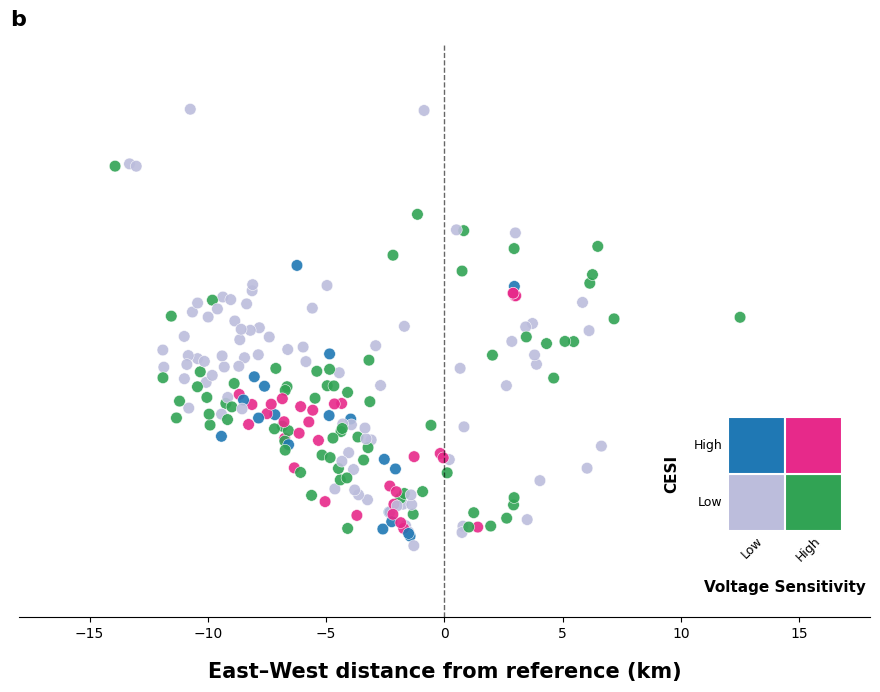

In [38]:
custom_colors = {
    ('Low', 'Low'): '#bcbddc',
    ('High', 'Low'): '#31a354',
    ('Low', 'High'): '#1f78b4',
    ('High', 'High'): '#e7298a'
}

coef_temp_neg = plot_site_coef_bivariate(
    sensor_ols_gdf_filt,
    value_col='coef_Temp',
    quadrant_colors=custom_colors,

    x_label_fontsize=15,
    x_rotation=0,

    # Panel label
    panel_label='b',
    panel_label_x=-0.01,
    panel_label_y=1.06,
    panel_label_fontsize=16,

    use_union_centroid=True,
    use_km=True,

    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,

    diagnostics=False,

    legend_cell_size=0.10,
    legend_pos=(0.80, 0.15),
    legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=45,
    legend_x_label_offset=-0.85,
    legend_y_label_offset=-0.85,
    legend_x_tick_offset=-0.05,
    legend_y_tick_offset=-0.1,

    save_path=PLOTS_DIR / 'spatial_clustering_bivar_v1.png'
)